# The Market Runs on Volume Time — a quantitative teardown 🔬
### Kurtosis removed per clock · contemporaneous vs lagged · HAR-X vs HAR · a lagged overlay

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The companion to the [notebook for the curious](01_for_the_curious.ipynb). §1 measures how much
excess kurtosis Clark's volume clock removes against a range (upper) and GARCH (usual) benchmark
with paired block-bootstrap intervals; §2 separates the contemporaneous volume–volatility relation
from the lagged one; §3 races a range-based log-HAR against the same model with lagged volume, out
of sample, with HAC Diebold–Mariano tests; §4 builds the overlay with one execution lag and a cost
sweep; §5 is the synthetic positive/negative control.

> ⚠️ **Not investment advice.** S&P 500 and Nasdaq Composite **price indices**
> (dividends excluded), composite index volume, frozen inside `arch` and SHA-256 pinned via
> `quantlab.bundled`; as-of **2018-12-31**. The reproducible run is
> [`docs/results.md`](../docs/results.md).
>
> 💡 **The `In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
plt.rcParams["figure.dpi"] = 80
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.width", 160)
from volclock import data, strategy as st
tapes = data.load_all()
print(f"as-of {data.AS_OF} | source: {data.SOURCE}")
for n, t in tapes.items():
    print(f"  {data.TAPE_LABELS[n]:32s} {t.index[0].date()} -> {t.index[-1].date()}  "
          f"{len(t):,} sessions  fingerprint {data.fingerprint(t)}")

as-of 2018-12-31 | source: arch (bundled data, via quantlab.bundled.load_arch)
  S&P 500 (price index)            1999-01-04 -> 2018-12-31  5,031 sessions  fingerprint 2da6b3800e6c
  Nasdaq Composite (price index)   1999-01-04 -> 2018-12-31  5,031 sessions  fingerprint 2a173ef678c8


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Weak | Divide each day's return by the square root of that day's volume (relative to its own past-only 63-day median) and the excess kurtosis moves — S&P 500 from **9.2 to 7.9**, 14% of it removed (block-bootstrap 95% CI -12% to 26%); Nasdaq from **6.2 to 4.9**, 21% of it removed (block-bootstrap 95% CI 1% to 38%). The correlation of volume with the absolute return is S&P 500 +0.22 on the same day (Newey–West t 8.3) against +0.11 with the next day; Nasdaq +0.19 on the same day (Newey–West t 8.3) against +0.05 with the next day. The link is unmistakable but the clock is a weak one: on its own it misses the pre-registered bar (at least 25% of the excess kurtosis removed, bootstrap CI above zero) on both tapes. Nor does it make returns Gaussian: Jarque–Bera still rejects normality in volume time on every tape. The benchmarks bracket it: the day's own range (an upper bound, since it *is* that day's volatility) removes S&P 500 110%; Nasdaq 99%, a past-only GARCH removes S&P 500 76%; Nasdaq 78%, and GARCH times same-day volume *surprise* removes S&P 500 82%; Nasdaq 89% — a further reduction over GARCH alone whose bootstrap CI excludes zero on Nasdaq. Most of the fat tail is volatility clustering, which a past-only model already sees; the volume clock adds a same-day sliver on top. |
| **Tradability** | Mirage | The clock is read at the close of the day it explains, so the usable question is whether **yesterday's** volume sharpens **tomorrow's** variance forecast beyond a range-based log-HAR. Out of sample (monthly refits, expanding window), adding lagged relative volume moves next-day QLIKE on squared returns with a Diebold–Mariano t of S&P 500 **+0.95** (p 0.34); Nasdaq **+0.12** (p 0.90) — negative would favour volume. Against the range-variance target the DM t is S&P 500 -0.10; Nasdaq -1.77. Built into a 15%-target vol overlay traded one session after the forecast, at 2 bp one-way, the volume-aware overlay's Sharpe minus the plain HAR overlay's is S&P 500 **+0.001** (bootstrap p 0.80); Nasdaq **+0.000** (bootstrap p 0.95). (The range-based HAR is itself the better forecaster — against GARCH its QLIKE DM t is S&P 500 -5.2; Nasdaq -5.4 — so the benchmark being beaten is not a straw man.) The impossible version — sizing today's position by today's volume, which nobody has until after the close — moves the gross Sharpe of a zero-lag HAR overlay from S&P 500 0.37 to 0.47; Nasdaq 0.52 to 0.64: whatever the clock is worth sits on the wrong side of the close. |

> 💡 **In plain words.** Volume and volatility move together, but volume time is a weak clock: dividing by same-day volume removes 14%–21% of the excess kurtosis of daily index returns and leaves them far from normal, and by the time anyone can read the clock it is spent — lagged volume adds nothing significant to a range-based HAR forecast and nothing to a vol-targeting overlay.

## 0 · Hypotheses (fixed before the run — `strategy.verdict`)

- **H₁ (clock).** `r_t / sqrt(V_t / median(V_{t-63..t-1}))` removes ≥ 25% of the raw excess
  kurtosis with a block-bootstrap 95% CI above zero, on **both** tapes.
- **H₂ (link).** Contemporaneous corr(log relative volume, |r|) has a Newey–West t ≥ 2.
- **H₁ ∧ H₂ on both tapes → Real**; holds on one while the other removes nothing → Mixed; positive
  removal everywhere but the bar missed somewhere → Weak.
- **H₃ (forecast).** Lagged log relative volume added to a log-HAR on Parkinson variance lowers
  next-day QLIKE on r² with DM t ≤ −2.
- **H₄ (overlay).** The HAR-X vol-target overlay beats the HAR overlay net of 2 bp with block-
  bootstrap p < 0.05. H₃ ∧ H₄ on both tapes → Investable; H₃ and a positive net gain on one tape →
  Fragile; else Mirage.

## 1 · Kurtosis removed per clock

All five series on the same sessions (two years of burn for the past-only GARCH), each rescaled
to unit variance. Paired circular block bootstrap, 21-day blocks.

In [2]:
panels, K = {}, {}
for n, t in tapes.items():
    panels[n] = st.clock_panel(t)
    K[n] = st.kurtosis_removed(panels[n], n_boot=500)
    print(f"\n{data.TAPE_LABELS[n]} — {len(panels[n]):,} sessions from {panels[n].index[0].date()}")
    print(K[n][["excess_kurtosis", "kurt_ci_lo", "kurt_ci_hi", "share_removed",
                "share_ci_lo", "share_ci_hi", "jb", "jb_p"]].round(3).to_string())


S&P 500 (price index) — 4,526 sessions from 2001-01-03
              excess_kurtosis  kurt_ci_lo  kurt_ci_hi  share_removed  share_ci_lo  share_ci_hi          jb   jb_p
clock                                                                                                            
raw                    9.1890      3.4480     13.2870         0.0000       0.0000       0.0000 15,964.0660 0.0000
volume                 7.8730      2.8920     11.0610         0.1430      -0.0900       0.2590 11,756.4720 0.0000
range                 -0.9210     -1.0820     -0.6860         1.1000       1.0610       1.2740    160.0780 0.0000
garch                  2.2290      1.0530      3.6370         0.7570       0.2880       0.8950  1,149.3430 0.0000
garch_volume           1.6270      0.7590      2.3900         0.8230       0.5100       0.9140    623.0930 0.0000



Nasdaq Composite (price index) — 4,524 sessions from 2001-01-03
              excess_kurtosis  kurt_ci_lo  kurt_ci_hi  share_removed  share_ci_lo  share_ci_hi         jb   jb_p
clock                                                                                                           
raw                    6.2350      3.2710      8.8500         0.0000       0.0000       0.0000 7,330.0740 0.0000
volume                 4.9060      2.6650      6.7430         0.2130      -0.0000       0.3750 4,545.6700 0.0000
range                  0.0810     -0.1950      0.4080         0.9870       0.9260       1.0370    23.0940 0.0000
garch                  1.3710      0.7610      1.9320         0.7800       0.5460       0.8750   487.1460 0.0000
garch_volume           0.6620      0.3310      0.9970         0.8940       0.7810       0.9410   148.8570 0.0000


> 💡 **In plain words.** The volume clock removes a seventh to a fifth of the fat-tailedness;
> its interval touches zero on the S&P. Jarque–Bera rejects normality under every clock — even the
> range clock, which over-corrects into *thin* tails on the S&P because a close-to-close move
> cannot exceed the day's range when there is no overnight gap.

In [3]:
for n in tapes:
    print(f"\n{data.TAPE_LABELS[n]} — tails of each clock (unit variance) against N(0,1)")
    print(st.tail_table(panels[n]).round(2).to_string())


S&P 500 (price index) — tails of each clock (unit variance) against N(0,1)
               q0.1%     q1%   q99%  q99.9%  beyond3_vs_normal  beyond4_vs_normal
clock                                                                            
raw          -5.7900 -2.9000 2.8300  5.2000             6.4700           108.1300
volume       -5.7000 -2.7900 2.7700  4.9600             6.3000           115.1100
range        -2.1000 -1.6900 2.0000  2.7000             0.0800             3.4900
garch        -4.5500 -2.7200 2.3100  3.1100             3.1900            31.3900
garch_volume -4.5500 -2.6100 2.2200  3.1100             2.2900            31.3900

Nasdaq Composite (price index) — tails of each clock (unit variance) against N(0,1)
               q0.1%     q1%   q99%  q99.9%  beyond3_vs_normal  beyond4_vs_normal
clock                                                                            
raw          -4.7500 -2.7900 2.7800  5.2500             5.6500            80.2600
volume       -4.450

### 1.1 Robustness: exponent, detrending window, sub-periods

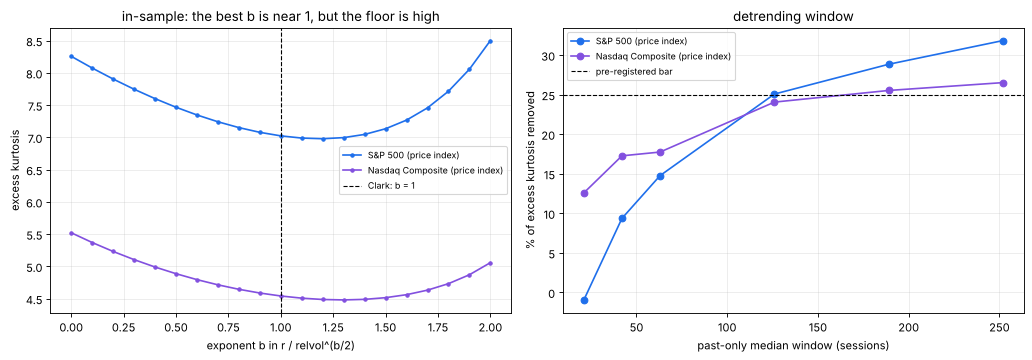

S&P 500 (price index)
              n  k_raw  share_volume  share_range  share_garch  share_garch_volume
period                                                                            
2001-2007  1757 2.7000        0.2600       1.4700       0.1700              0.6300
2008-2012  1259 6.9700        0.1700       1.1600       0.8600              0.7500
2013-2018  1510 3.6500        0.2900       1.1800       0.0100              0.4100

Nasdaq Composite (price index)
              n  k_raw  share_volume  share_range  share_garch  share_garch_volume
period                                                                            
2001-2007  1757 4.9700        0.3900       1.0800       0.8100              0.9500
2008-2012  1259 5.1600        0.0900       0.9000       0.8200              0.9100
2013-2018  1508 3.0400        0.2400       0.9900       0.2400              0.5500



In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for (n, t), c in zip(tapes.items(), ("#1f6feb", "#8250df")):
    E = st.exponent_curve(t)
    axes[0].plot(E.index, E.values, "o-", ms=3, color=c, label=data.TAPE_LABELS[n])
    W = st.window_sensitivity(t, windows=(21, 42, 63, 126, 189, 252))
    axes[1].plot(W.index, W["share_removed"] * 100, "o-", color=c, label=data.TAPE_LABELS[n])
axes[0].axvline(1.0, color="k", ls="--", lw=1, label="Clark: b = 1")
axes[0].set_xlabel("exponent b in r / relvol^(b/2)"); axes[0].set_ylabel("excess kurtosis")
axes[0].set_title("in-sample: the best b is near 1, but the floor is high")
axes[1].axhline(25, color="k", ls="--", lw=1, label="pre-registered bar")
axes[1].set_xlabel("past-only median window (sessions)")
axes[1].set_ylabel("% of excess kurtosis removed"); axes[1].set_title("detrending window")
for a in axes:
    a.legend(fontsize=8)
plt.tight_layout(); plt.show()
for n in tapes:
    print(data.TAPE_LABELS[n]); print(st.by_period(panels[n]).round(2).to_string()); print()

> 💡 **In plain words.** Clark's square-root exponent is roughly the right shape — the
> kurtosis curve bottoms out near b ≈ 1.2 — but the bottom is high. A slower detrend (a year
> rather than a quarter) helps the S&P clock, which says part of what the 63-day median calls
> "unusual volume" is really a slow level shift in how the index volume is counted. Even the most
> favourable window — chosen *after* looking — stays near a third.

### 1.2 Does volume add anything *on top of* GARCH?

Lamoureux & Lastrapes (1990) found that putting same-day volume into the GARCH variance equation
absorbs much of the GARCH persistence. Here: excess kurtosis of the GARCH residual minus that of the
GARCH residual divided by sqrt(volume surprise), paired bootstrap.

In [5]:
pd.DataFrame({data.TAPE_LABELS[n]: st.incremental_removal(panels[n], n_boot=500)
              for n in tapes}).T

,a,b,kurt_reduction,ci_lo,ci_hi,share_boot_positive
S&P 500 (price index),garch_volume,garch,0.6016,-0.1906,1.5416,0.9360
Nasdaq Composite (price index),garch_volume,garch,0.7082,0.4036,1.0541,1.0000


## 2 · The volume–volatility correlation: same day vs later

Standardised series, so the HAC slope is the correlation. The cross-correlogram shows how fast
the link decays.

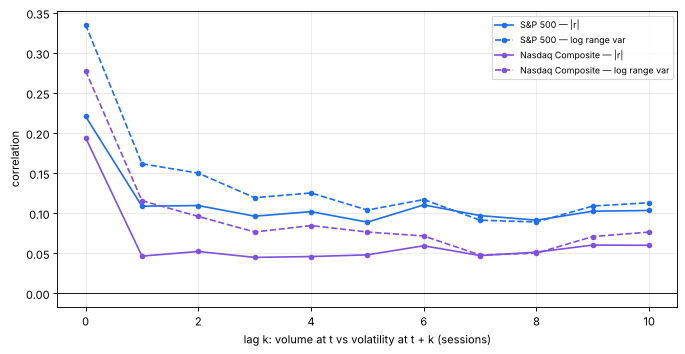

S&P 500 (price index)
 lag        target   corr   hac_t  spearman    n
   0           |r| 0.2210  8.2520    0.2190 5000
   0 log range var 0.3360 11.0830    0.3310 5000
   1           |r| 0.1090  3.7190    0.0740 4999
   1 log range var 0.1620  5.6710    0.1510 4999
   5           |r| 0.0890  3.4790    0.0700 4995
   5 log range var 0.1040  3.7200    0.1220 4995

Nasdaq Composite (price index)
 lag        target   corr   hac_t  spearman    n
   0           |r| 0.1940  8.2620    0.1900 4998
   0 log range var 0.2780 10.7160    0.2660 4998
   1           |r| 0.0470  1.8770    0.0320 4997
   1 log range var 0.1160  4.6250    0.1090 4997
   5           |r| 0.0480  2.3800    0.0520 4993
   5 log range var 0.0770  3.0680    0.0980 4993



In [6]:
fig, ax = plt.subplots(figsize=(10, 4.8))
for (n, t), c in zip(tapes.items(), ("#1f6feb", "#8250df")):
    C = st.volume_vol_correlation(t, lags=tuple(range(0, 11)))
    for tgt, ls in (("|r|", "-"), ("log range var", "--")):
        s = C[C["target"] == tgt]
        ax.plot(s["lag"], s["corr"], ls, marker="o", ms=4, color=c,
                label=f"{data.TAPE_LABELS[n].split(' (')[0]} — {tgt}")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("lag k: volume at t vs volatility at t + k (sessions)")
ax.set_ylabel("correlation"); ax.legend(fontsize=8); plt.show()
for n, t in tapes.items():
    print(data.TAPE_LABELS[n])
    print(st.volume_vol_correlation(t).round(3).to_string(index=False)); print()

> 💡 **In plain words.** The same-day link has a t-statistic above 8 on both tapes. It halves
> or worse by the next day, and what remains is the slow tail that every volatility measure shares
> — the part a range-based HAR already sees.

## 3 · Does *lagged* volume improve tomorrow's forecast?

Out of sample from 2002. HAR = log-HAR on Parkinson variance (day / week / month); HAR-X adds
log relative volume at the forecast day's close. Monthly refits on an expanding window, the same
past-only calibration to the variance level. GARCH(1,1) refitted yearly. QLIKE in Patton's
`a/f + log f` form; HAC Diebold–Mariano; negative t favours HAR-X.

In [7]:
races, fcs = {}, {}
for n, t in tapes.items():
    fcs[n] = st.forecast_race(t)
    races[n] = st.score_race(fcs[n])
    print(data.TAPE_LABELS[n])
    print(races[n][["target", "loss", "vs", "n", "mean_diff", "dm_t", "p"]]
          .round(4).to_string(index=False)); print()

S&P 500 (price index)
target  loss    vs    n  mean_diff    dm_t      p
    r2 qlike   har 4274     0.0011  0.9521 0.3411
    r2 qlike garch 4274    -0.0493 -5.1788 0.0000
    r2   mse   har 4274    -0.0000 -0.3930 0.6944
    r2   mse garch 4274    -0.0000 -1.3513 0.1766
    pk qlike   har 4274    -0.0001 -0.1035 0.9176
    pk qlike garch 4274    -0.0468 -7.6570 0.0000
    pk   mse   har 4274    -0.0000 -0.5705 0.5683
    pk   mse garch 4274    -0.0000 -1.8793 0.0602



Nasdaq Composite (price index)
target  loss    vs    n  mean_diff    dm_t      p
    r2 qlike   har 4272     0.0001  0.1237 0.9016
    r2 qlike garch 4272    -0.0497 -5.3972 0.0000
    r2   mse   har 4272    -0.0000 -0.0410 0.9673
    r2   mse garch 4272    -0.0000 -1.5728 0.1158
    pk qlike   har 4272    -0.0006 -1.7682 0.0770
    pk qlike garch 4272    -0.0423 -6.8729 0.0000
    pk   mse   har 4272     0.0000  0.7239 0.4691
    pk   mse garch 4272    -0.0000 -2.0612 0.0393



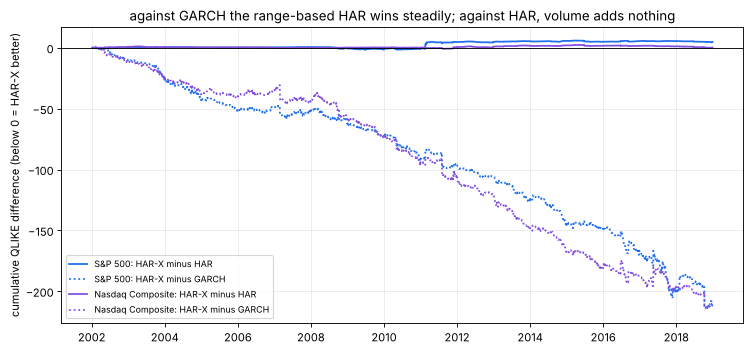

,beta_lv,t_lv,r2_har,r2_harx,n
S&P 500 (price index),0.1259,1.5268,0.5458,0.5461,"4,999.0000"
Nasdaq Composite (price index),0.1326,1.8358,0.5885,0.5888,"4,997.0000"


In [8]:
fig, ax = plt.subplots(figsize=(11, 4.8))
for (n, fc), c in zip(fcs.items(), ("#1f6feb", "#8250df")):
    d = fc[["har_r2", "harx_r2", "garch_r2", "target_r2"]].dropna()
    a = d["target_r2"].to_numpy()
    for other, ls in (("har", "-"), ("garch", ":")):
        diff = st.qlike(a, d["harx_r2"]) - st.qlike(a, d[f"{other}_r2"])
        ax.plot(d.index, np.cumsum(diff), ls, color=c, lw=1.6,
                label=f"{data.TAPE_LABELS[n].split(' (')[0]}: HAR-X minus {other.upper()}")
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("cumulative QLIKE difference (below 0 = HAR-X better)")
ax.set_title("against GARCH the range-based HAR wins steadily; against HAR, volume adds nothing")
ax.legend(fontsize=8); plt.show()
pd.DataFrame({data.TAPE_LABELS[n]: st.har_in_sample(t) for n, t in tapes.items()}).T

> 💡 **In plain words.** The dotted lines fall steadily: a model built on the daily price
> range beats GARCH, as study 965 found for range estimators generally. The solid lines wander
> around zero: once the range is in the model, yesterday's volume tells it nothing new. Even
> in-sample, with every advantage, the volume coefficient's Newey–West t stays under 2.

## 4 · The overlay — one execution lag, costs, Sharpe race

Weight `min(1.5, 15% / forecast vol)`; forecast at close t, **traded at close t+1** (the day's
composite volume is published after the close), earning t+2. Cash at Fama–French RF (December 2018
carries November); costs one-way × |Δweight|; price-only excess returns.

In [9]:
ovs = {}
for n, t in tapes.items():
    rf = data.load_daily_rf(t.index)
    ovs[n] = st.overlay_race(t, fcs[n], rf, n_boot=500)
    print(f"{data.TAPE_LABELS[n]}  {ovs[n]['start']} -> {ovs[n]['end']}  ({ovs[n]['n']:,} sessions)")
    print(ovs[n]["table"].round(3).to_string(index=False))
    print(ovs[n]["tests"].round(3).to_string(index=False)); print()

S&P 500 (price index)  2002-01-11 -> 2018-12-31  (4,272 sessions)
 cost_bps      model  sharpe  ann_ret  ann_vol  turnover_ann  mean_pos
   0.0000        har  0.3560   0.0520   0.1470        9.8820    1.0950
   0.0000       harx  0.3570   0.0520   0.1470        9.8830    1.0960
   0.0000      garch  0.3520   0.0510   0.1440        7.3860    1.0470
   2.0000        har  0.3430   0.0500   0.1470        9.8820    1.0950
   2.0000       harx  0.3430   0.0510   0.1470        9.8830    1.0960
   2.0000      garch  0.3420   0.0490   0.1440        7.3860    1.0470
   5.0000        har  0.3220   0.0470   0.1470        9.8820    1.0950
   5.0000       harx  0.3230   0.0480   0.1470        9.8830    1.0960
   5.0000      garch  0.3260   0.0470   0.1440        7.3860    1.0470
  10.0000        har  0.2890   0.0420   0.1470        9.8820    1.0950
  10.0000       harx  0.2900   0.0430   0.1470        9.8830    1.0960
  10.0000      garch  0.3010   0.0430   0.1440        7.3860    1.0470
   0.0000 b

Nasdaq Composite (price index)  2002-01-11 -> 2018-12-31  (4,272 sessions)
 cost_bps      model  sharpe  ann_ret  ann_vol  turnover_ann  mean_pos
   0.0000        har  0.4990   0.0740   0.1470       14.7470    0.9120
   0.0000       harx  0.4990   0.0740   0.1470       14.7060    0.9120
   0.0000      garch  0.4690   0.0680   0.1450        6.4330    0.8680
   2.0000        har  0.4790   0.0710   0.1470       14.7470    0.9120
   2.0000       harx  0.4790   0.0710   0.1470       14.7060    0.9120
   2.0000      garch  0.4600   0.0670   0.1450        6.4330    0.8680
   5.0000        har  0.4490   0.0660   0.1470       14.7470    0.9120
   5.0000       harx  0.4490   0.0660   0.1470       14.7060    0.9120
   5.0000      garch  0.4470   0.0650   0.1450        6.4330    0.8680
  10.0000        har  0.3990   0.0590   0.1470       14.7470    0.9120
  10.0000       harx  0.3990   0.0590   0.1470       14.7060    0.9120
  10.0000      garch  0.4250   0.0610   0.1450        6.4330    0.8680
  

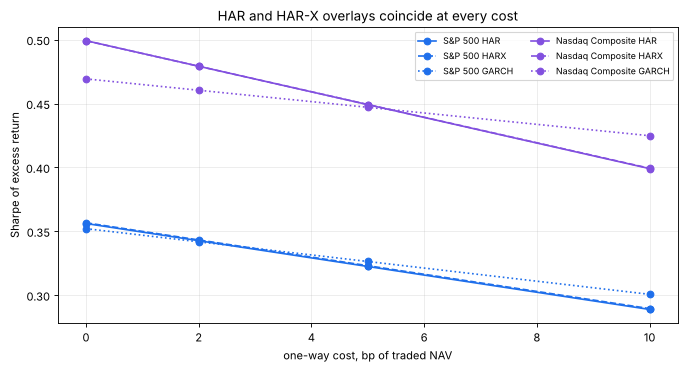

S&P 500 (price index)            zero-lag HAR 0.37 -> x SAME-DAY volume (look-ahead, impossible) 0.47
Nasdaq Composite (price index)   zero-lag HAR 0.52 -> x SAME-DAY volume (look-ahead, impossible) 0.64


In [10]:
fig, ax = plt.subplots(figsize=(10, 4.8))
for (n, o), c in zip(ovs.items(), ("#1f6feb", "#8250df")):
    tb = o["table"]
    for m, ls in (("har", "-"), ("harx", "--"), ("garch", ":")):
        s = tb[tb["model"] == m]
        ax.plot(s["cost_bps"], s["sharpe"], ls, marker="o", color=c,
                label=f"{data.TAPE_LABELS[n].split(' (')[0]} {m.upper()}")
ax.set_xlabel("one-way cost, bp of traded NAV"); ax.set_ylabel("Sharpe of excess return")
ax.set_title("HAR and HAR-X overlays coincide at every cost"); ax.legend(fontsize=8, ncol=2)
plt.show()
for n, t in tapes.items():
    la = st.lookahead_clock_sharpe(t, fcs[n], data.load_daily_rf(t.index))
    print(f"{data.TAPE_LABELS[n]:32s} zero-lag HAR {la['sharpe_zero_lag']:.2f} -> "
          f"x SAME-DAY volume (look-ahead, impossible) {la['sharpe_gross']:.2f}")

> 💡 **In plain words.** Sizing by *today's* volume — information that does not exist until
> after the close — would add about a tenth of a Sharpe point. Lag it by the one day reality
> imposes and the gain is ±0.001, with a bootstrap interval that straddles zero at every cost. The
> clock is real; its value is on the wrong side of the close.

## 5 · Synthetic control — machinery, not evidence

`data.synthetic_tape`: returns N(0, σ²·m_t) realised on an intraday Brownian path (so high and low
exist), with `signal_strength` the share of `log m_t` carried by the volume clock. Raw tails are the
same at every setting; only the link to volume moves.

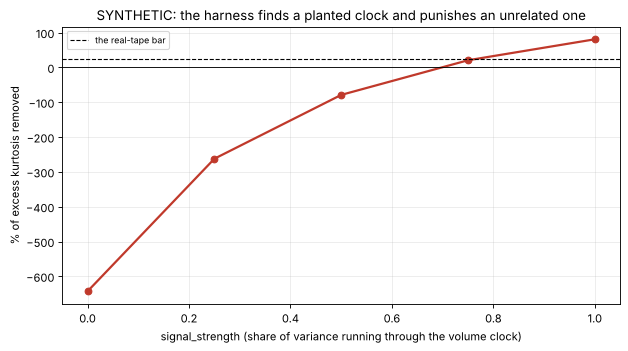

,k_raw,k_volume,share_removed,dm_t_harx_vs_har
signal_strength,,,,
0.0000,2.3190,17.2300,-6.4300,0.7120
0.2500,1.6510,5.9790,-2.6210,-0.4070
0.5000,1.5550,2.7800,-0.7880,-1.3250
0.7500,1.5140,1.2000,0.2070,-2.0760
1.0000,1.5480,0.2950,0.8090,-2.3570


In [11]:
rows = []
for s in (0.0, 0.25, 0.5, 0.75, 1.0):
    tp, truth = data.synthetic_tape(n_days=4000, signal_strength=s, seed=1019)
    Ps = st.clock_panel(tp)
    kr = st.moments(Ps["raw"])["excess_kurtosis"]
    kv = st.moments(Ps["volume"])["excess_kurtosis"]
    S = st.score_race(st.forecast_race(tp))
    dm = S[(S["target"] == "pk") & (S["loss"] == "qlike") & (S["vs"] == "har")]["dm_t"].iloc[0]
    rows.append({"signal_strength": s, "k_raw": kr, "k_volume": kv,
                 "share_removed": 1 - kv / kr, "dm_t_harx_vs_har": dm})
syn = pd.DataFrame(rows).set_index("signal_strength")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(syn.index, syn["share_removed"] * 100, "o-", color="#c0392b", lw=2)
ax.axhline(0, color="k", lw=0.8); ax.axhline(25, color="k", ls="--", lw=1, label="the real-tape bar")
ax.set_xlabel("signal_strength (share of variance running through the volume clock)")
ax.set_ylabel("% of excess kurtosis removed"); ax.legend(fontsize=8)
ax.set_title("SYNTHETIC: the harness finds a planted clock and punishes an unrelated one")
plt.show()
syn.round(3)

> 💡 **In plain words.** Where Clark is true by construction, the same code removes most of
> the excess kurtosis and finds a forecast gain; where the clock is unrelated, dividing by it makes
> the tails *fatter*. The real tapes sit near the low end of this dial — and these synthetic numbers
> say nothing about markets, only that the machinery can see what it is looking for.

## 6 · Could you trade it?

Venue: index futures or a large ETF, where one-way costs of 1–2 bp are realistic and capacity is
not the constraint. Risk: the overlay is long the index ~90–110% of the time; vol-targeting itself
is a known, modest improvement over buy-and-hold on these tapes (both HAR overlays beat holding on
Sharpe), and that improvement belongs to the range-based forecast, not to volume. The volume-aware
version changes turnover and Sharpe by amounts too small to measure. Nothing here is a reason to
pay for a volume feed.

## 7 · Going further

- **Trade-count clock on single names, intraday** — the Ané–Geman setting, which daily index data
  cannot reach. The desk's `quantlab/hf_data.py` is the place to start.
- **Volume surprise as a same-day risk signal.** §1.2 shows volume surprise thins the GARCH
  residual's tails on the Nasdaq. For *ex-post* risk attribution (why was today's P&L large?) that
  is useful even though it does not forecast.
- **Asymmetry.** Volume rises more on down days; a signed clock combined with the leverage effect
  (study 993) is an obvious fork.
- **Challenge us:** the 25% bar, the 63-day window and the log-HAR form are all choices; each is a
  one-line change in `volclock/strategy.py`, and `examples/verify.py` regenerates everything.